# Exercício 1 - Neurônio de McCulloch e Pitts

In [ ]:

# Tabela:
# x1 x2 x3 | y
# 0  0  0  | 0
# 0  0  1  | 0
# 0  1  0  | 0
# 0  1  1  | 0
# 1  0  0  | 0
# 1  0  1  | 0
# 1  1  0  | 1
# 1  1  1  | 0

# Solução:
# - Pesos: w1=1, w2=1, w3=-2 (x3 é inibitória)
# - Limiar (theta): 2

# Verificação:
# Para [1, 1, 0]: 1+1+0*(-2) = 2 (Ativa -> y=1)
# Para [1, 1, 1]: 1+1+(-2) = 0 (Não ativa -> y=0)


# Exercício 2 - É possível classificar XOR com McCulloch e Pitts ou Perceptron?

In [ ]:

# Não é possível classificar XOR com McCulloch e Pitts nem com perceptron simples.
# XOR não é linearmente separável.
# Necessário uma rede com pelo menos uma camada oculta (MLP).


# Exercício 3 - Por que usar regressão logística em vez de perceptron?

In [ ]:

# O perceptron só funciona quando os dados são linearmente separáveis.
# A regressão logística funciona também para dados não separáveis, pois usa
# função sigmoide e minimiza a entropia cruzada.

# Para transformar um perceptron em regressão logística:
# - Substituir a função de ativação degrau pela função sigmoide.
# - Usar a função de custo de log-loss (entropia cruzada).


# Exercício 4 - Implementação do Perceptron para AND e OR

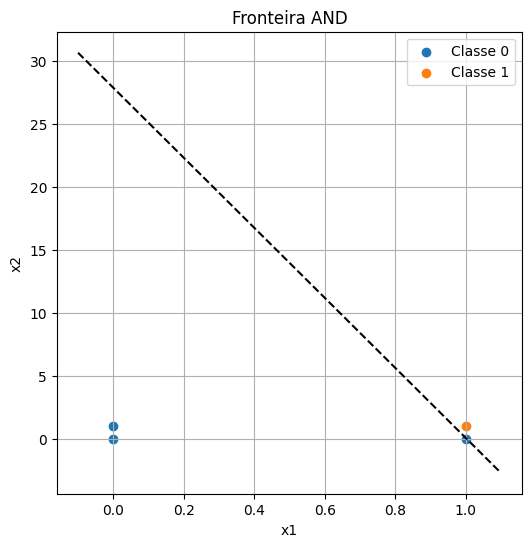

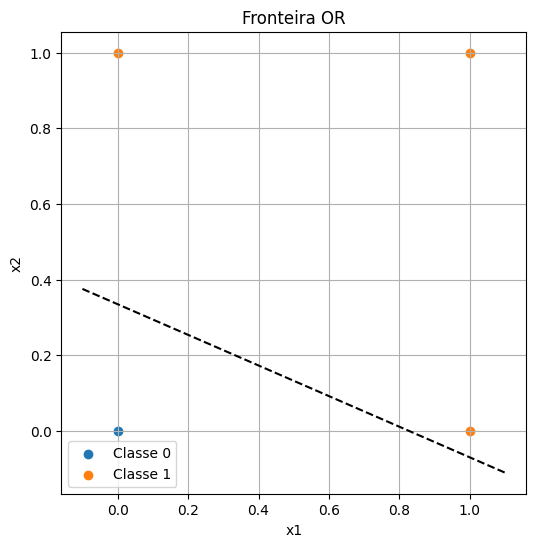

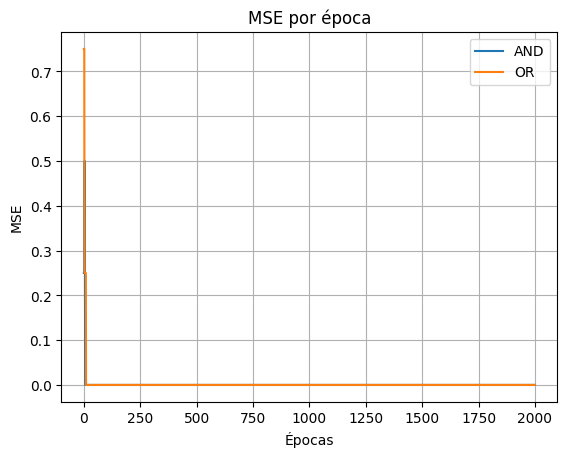

In [1]:

import numpy as np
import matplotlib.pyplot as plt

def perceptron(X, y, alpha=0.1, n_epochs=2000):
    X = np.c_[np.ones(X.shape[0]), X]  # Bias
    w = np.random.randn(X.shape[1])
    mse_list = []

    for epoch in range(n_epochs):
        mse_epoch = 0
        for i in np.random.permutation(len(y)):
            xi = X[i]
            yi = y[i]
            pred = np.where(np.dot(xi, w) >= 0, 1, 0)
            error = yi - pred
            w += alpha * error * xi
            mse_epoch += error**2
        mse_list.append(mse_epoch / len(y))
    return w, mse_list

# Dados AND e OR
X_and = np.array([[0,0],[0,1],[1,0],[1,1]])
y_and = np.array([0,0,0,1])
X_or = np.array([[0,0],[0,1],[1,0],[1,1]])
y_or = np.array([0,1,1,1])

# Treinar
w_and, mse_and = perceptron(X_and, y_and)
w_or, mse_or = perceptron(X_or, y_or)

# Fronteiras
def plot_boundary(w, X, y, title):
    plt.figure(figsize=(6,6))
    plt.scatter(X[y==0, 0], X[y==0, 1], label='Classe 0')
    plt.scatter(X[y==1, 0], X[y==1, 1], label='Classe 1')
    x1 = np.linspace(-0.1, 1.1, 100)
    x2 = -(w[0] + w[1]*x1)/w[2]
    plt.plot(x1, x2, 'k--')
    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend()
    plt.grid()
    plt.show()

plot_boundary(w_and, X_and, y_and, 'Fronteira AND')
plot_boundary(w_or, X_or, y_or, 'Fronteira OR')

# MSE
plt.figure()
plt.plot(mse_and, label='AND')
plt.plot(mse_or, label='OR')
plt.title('MSE por época')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.legend()
plt.grid()
plt.show()


# Exercício 5 - Comparação entre Perceptron e Regressão Logística

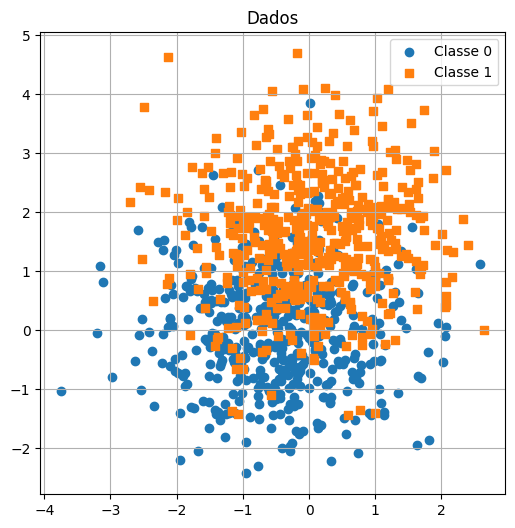

Acurácia Perceptron: 0.762


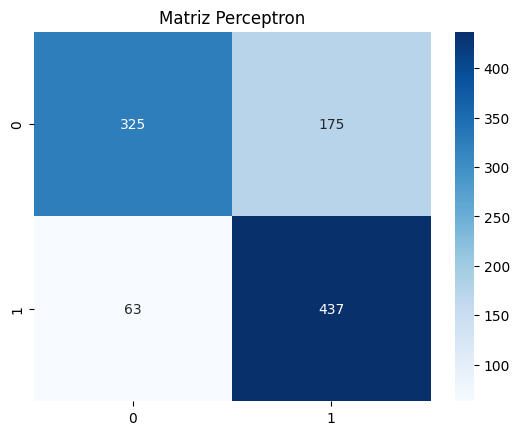

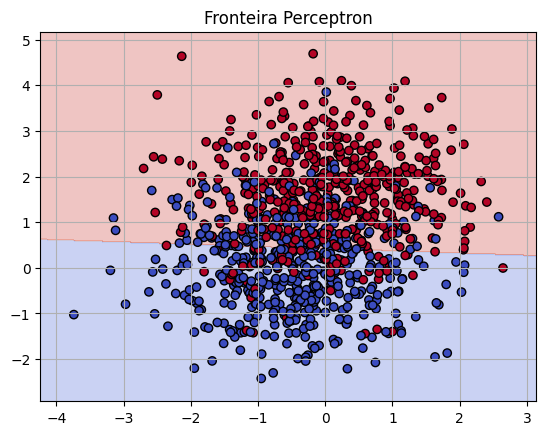

Acurácia Logistic Regression: 0.797


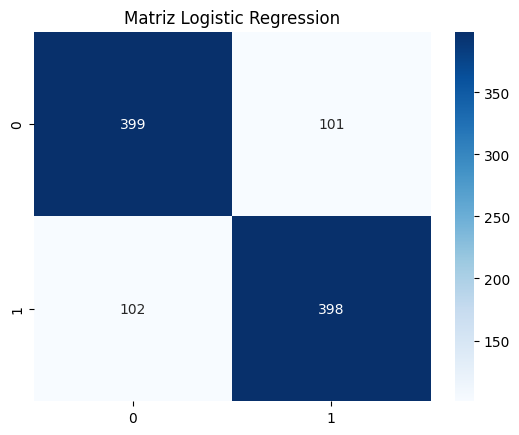

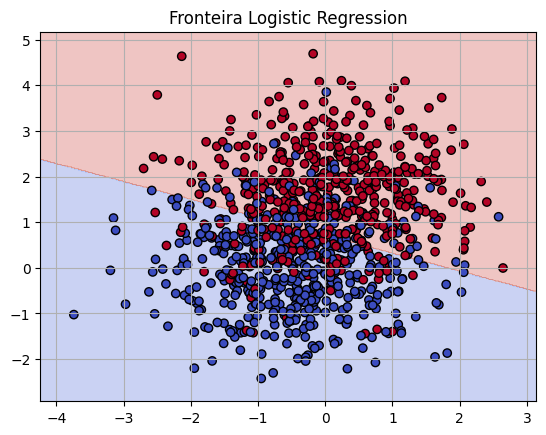

Conclusão:
Acurácia Perceptron: 0.7620
Acurácia Logistic Regression: 0.7970


In [2]:

from sklearn.datasets import make_blobs
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# Dados
N = 1000
centers = [[-0.5, 0], [0, 1.5]]
X, y = make_blobs(n_samples=N, centers=centers, random_state=42)

# Visualizar
plt.figure(figsize=(6,6))
plt.scatter(X[y==0, 0], X[y==0, 1], label='Classe 0', marker='o')
plt.scatter(X[y==1, 0], X[y==1, 1], label='Classe 1', marker='s')
plt.title('Dados')
plt.legend()
plt.grid()
plt.show()

# Perceptron
per = Perceptron(random_state=42)
per.fit(X, y)
y_pred_per = per.predict(X)
acc_per = accuracy_score(y, y_pred_per)
print('Acurácia Perceptron:', acc_per)

# Matriz de confusão
sns.heatmap(confusion_matrix(y, y_pred_per), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz Perceptron')
plt.show()

# Fronteira Perceptron
xx, yy = np.meshgrid(np.arange(X[:,0].min()-0.5, X[:,0].max()+0.5, 0.02),
                      np.arange(X[:,1].min()-0.5, X[:,1].max()+0.5, 0.02))
Z = per.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k', cmap=plt.cm.coolwarm)
plt.title('Fronteira Perceptron')
plt.grid()
plt.show()

# Logistic Regression
logreg = LogisticRegression(solver='lbfgs', random_state=42)
logreg.fit(X, y)
y_pred_log = logreg.predict(X)
acc_log = accuracy_score(y, y_pred_log)
print('Acurácia Logistic Regression:', acc_log)

# Matriz
sns.heatmap(confusion_matrix(y, y_pred_log), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz Logistic Regression')
plt.show()

# Fronteira Logistic Regression
Z = logreg.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k', cmap=plt.cm.coolwarm)
plt.title('Fronteira Logistic Regression')
plt.grid()
plt.show()

print('Conclusão:')
print(f'Acurácia Perceptron: {acc_per:.4f}')
print(f'Acurácia Logistic Regression: {acc_log:.4f}')
